In [1]:
import pandas as pd

In [3]:
diarios = pd.read_csv('diarios.csv')
diarios.tail()

,Unnamed: 0,fecha,contagios,recuperados,fallecidos,importados,total_casos,total_recuperados,total_fallecidos,total_importados,...,mm_tasa_contagio,mm_tasa_recuperacion,mm_tasa_fallecimiento,tasa_transmision_25,tasa_transmision_50,tasa_transmision_75,tasa_recuperacion_25,tasa_recuperacion_50,tasa_recuperacion_75,Ro_50
60,2020-05-05,2020-05-05,641,219,10,5,8612,2268,414,831,...,8.625640,1.748625,0.271310,1.466359,2.070154,2.846461,0.297266,0.419670,0.577046,4.932812
61,2020-05-06,2020-05-06,347,94,16,0,8959,2362,430,831,...,7.498288,1.772485,0.283388,1.274709,1.799589,2.474435,0.301322,0.425396,0.584920,4.230382
62,2020-05-07,2020-05-07,497,75,12,6,9456,2437,442,837,...,7.925609,1.774456,0.254579,1.347353,1.902146,2.615451,0.301658,0.425869,0.585570,4.466501
63,2020-05-08,2020-05-08,595,44,9,1,10051,2481,451,838,...,8.014840,1.700675,0.217023,1.362523,1.923562,2.644897,0.289115,0.408162,0.561223,4.712741
64,2020-05-09,2020-05-09,444,88,0,0,10495,2569,451,838,...,8.102071,1.728561,0.156453,1.377352,1.944497,2.673683,0.293855,0.414855,0.570425,4.687175


In [5]:
diarios.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65 entries, 0 to 64
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             65 non-null     object 
 1   fecha                  65 non-null     object 
 2   contagios              65 non-null     int64  
 3   recuperados            65 non-null     int64  
 4   fallecidos             65 non-null     int64  
 5   importados             65 non-null     int64  
 6   total_casos            65 non-null     int64  
 7   total_recuperados      65 non-null     int64  
 8   total_fallecidos       65 non-null     int64  
 9   total_importados       65 non-null     int64  
 10  infectados             65 non-null     int64  
 11  tasa_contagio          65 non-null     float64
 12  tasa_recuperacion      65 non-null     float64
 13  tasa_fallecimiento     65 non-null     float64
 14  mm_tasa_contagio       65 non-null     float64
 15  mm_tasa_

In [6]:
diarios.columns

Index(['Unnamed: 0', 'fecha', 'contagios', 'recuperados', 'fallecidos',
       'importados', 'total_casos', 'total_recuperados', 'total_fallecidos',
       'total_importados', 'infectados', 'tasa_contagio', 'tasa_recuperacion',
       'tasa_fallecimiento', 'mm_tasa_contagio', 'mm_tasa_recuperacion',
       'mm_tasa_fallecimiento', 'tasa_transmision_25', 'tasa_transmision_50',
       'tasa_transmision_75', 'tasa_recuperacion_25', 'tasa_recuperacion_50',
       'tasa_recuperacion_75', 'Ro_50'],
      dtype='object')

In [11]:
import matplotlib.pyplot as plt

# Modelo SIR

In [7]:
def SIR(
    tasa_contagio,
    tasa_recuperacion,
    tasa_fallecimiento,
    importados=None,
    T=500,
    poblacion_inicial=10 ** 5,
):

    simulacion = pd.DataFrame({"t": range(T)})
    simulacion["pob_susceptible"] = 0.0
    simulacion["pob_infectada"] = 0.0
    simulacion["pob_recuperada"] = 0.0
    simulacion["pob_fallecida"] = 0.0
    simulacion["contagios"] = 0.0
    simulacion["recuperados"] = 0.0
    simulacion["fallecidos"] = 0.0

    simulacion.at[0, "pob_susceptible"] = poblacion_inicial - 1
    simulacion.at[0, "pob_infectada"] = 1

    if importados is None:
        importados = [0] * T
    elif len(importados) < T:
        importados = importados.tolist() + [0] * (T - len(importados))

    for t in range(1, T):

        simulacion.at[t, "contagios"] = (
            tasa_contagio[t]
            * simulacion.pob_infectada[t - 1]
            * (simulacion.pob_susceptible[t - 1] / poblacion_inicial)
            + importados[t]
        )

        simulacion.at[t, "fallecidos"] = (
            tasa_fallecimiento * simulacion.pob_infectada[t - 1]
        )

        simulacion.at[t, "recuperados"] = (
            tasa_recuperacion * simulacion.pob_infectada[t - 1]
        )

        simulacion.at[t, "pob_susceptible"] = (
            simulacion.pob_susceptible[t - 1] - simulacion.contagios[t]
        )
        simulacion.at[t, "pob_infectada"] = (
            simulacion.pob_infectada[t - 1]
            + simulacion.contagios[t]
            - simulacion.fallecidos[t]
            - simulacion.recuperados[t]
        )
        simulacion.at[t, "pob_recuperada"] = (
            simulacion.pob_recuperada[t - 1] + simulacion.recuperados[t]
        )
        simulacion.at[t, "pob_fallecida"] = (
            simulacion.pob_fallecida[t - 1] + simulacion.fallecidos[t]
        )

    return simulacion

# Optimización parámetros

In [ ]:
T = len(diarios)
sse_opt = None

tasa_opt_contagio_1 = diarios.tasa_contagio[5:18].mean() / 100
tasa_opt_contagio_2 = diarios.tasa_contagio[18:].mean() / 100
tasa_opt_recuperacion = diarios.tasa_recuperacion.mean() / 100
tasa_opt_fallecimiento = diarios.tasa_fallecimiento.mean() / 100


for cycle in range(10):

    print()
    print("Tasas:")
    print("   Contagio 1:    {:4.2f}%".format(tasa_opt_contagio_1 * 100.0))
    print("   Contagio 2:    {:4.2f}%".format(tasa_opt_contagio_2 * 100.0))
    print("   Recuperacion:  {:4.2f}%".format(tasa_opt_recuperacion * 100.0))
    print("   Fallecimiento: {:4.2f}%".format(tasa_opt_fallecimiento * 100.0))

    changed = False

    for tasa_contagio_1 in np.arange(0.0900, 0.2300, 0.0001):

        sim = SIR(
            tasa_contagio=[tasa_contagio_1] * 19 + [tasa_opt_contagio_2] * (T - 19),
            tasa_recuperacion=tasa_opt_recuperacion,
            tasa_fallecimiento=tasa_opt_fallecimiento,
            importados=diarios.importados,
            T=T,
            poblacion_inicial=48223786,
        )

        sse = np.power(
            np.array(sim.pob_infectada[:18]) - np.array(diarios.total_casos[:18]), 2
        ).sum()

        if sse_opt is None or sse < sse_opt:

            changed = True
            sse_opt = sse
            tasa_opt_contagio_1 = tasa_contagio_1

    for tasa_contagio_2 in np.arange(0.07, 0.12, 0.0001):

        sim = SIR(
            tasa_contagio=[tasa_opt_contagio_1] * 19 + [tasa_contagio_2] * (T - 19),
            tasa_recuperacion=tasa_opt_recuperacion,
            tasa_fallecimiento=tasa_opt_fallecimiento,
            importados=diarios.importados,
            T=T,
            poblacion_inicial=48223786,
        )

        sse = np.power(
            np.array(sim.pob_infectada[18:T]) - np.array(diarios.total_casos[18:T]), 2
        ).sum()

        if sse_opt is None or sse < sse_opt:

            changed = True
            sse_opt = sse
            tasa_opt_contagio_2 = tasa_contagio_2

    for tasa_recuperacion in np.arange(0.000, 0.003, 0.00001,):

        sim = SIR(
            tasa_contagio=[tasa_opt_contagio_1] * 19 + [tasa_opt_contagio_2] * (T - 19),
            tasa_recuperacion=tasa_recuperacion,
            tasa_fallecimiento=tasa_opt_fallecimiento,
            importados=diarios.importados,
            T=T,
            poblacion_inicial=48223786,
        )

        sse = np.power(
            np.array(sim.pob_recuperada[:T]) - np.array(diarios.total_recuperados[:T]),
            2,
        ).sum()

        if sse_opt is None or sse < sse_opt:

            changed = True
            sse_opt = sse
            tasa_opt_recuperacion = tasa_recuperacion

    for tasa_fallecimiento in np.arange(0.00, 0.01, 0.0001,):

        sim = SIR(
            tasa_contagio=[tasa_opt_contagio_1] * 19 + [tasa_opt_contagio_2] * (T - 19),
            tasa_recuperacion=tasa_opt_recuperacion,
            tasa_fallecimiento=tasa_fallecimiento,
            importados=diarios.importados,
            T=T,
            poblacion_inicial=48223786,
        )

        sse = np.power(
            np.array(sim.pob_fallecida[:T]) - np.array(diarios.total_fallecidos[:T]), 2
        ).sum()

        if sse_opt is None or sse < sse_opt:

            changed = True
            sse_opt = sse
            tasa_opt_fallecimiento = tasa_fallecimiento

    if changed is False:
        break

print()
print("Tasas optimas:")
print("   Contagio 1:    {:4.2f}%".format(tasa_opt_contagio_1 * 100.0))
print("   Contagio 2:    {:4.2f}%".format(tasa_opt_contagio_2 * 100.0))
print("   Recuperacion:  {:4.2f}%".format(tasa_opt_recuperacion * 100.0))
print("   Fallecimiento: {:4.2f}%".format(tasa_opt_fallecimiento * 100.0))


Tasas:
   Contagio 1:    20.06%
   Contagio 2:    8.85%
   Recuperacion:  2.56%
   Fallecimiento: 0.43%


# Simulación finalización cuarentena

In [9]:
T = 81 # dato 80 - 24 de mayo de 2020 a la media noche

sim = SIR(
    tasa_contagio=[tasa_opt_contagio_1] * 19 + [tasa_opt_contagio_2] * (T - 19),
    tasa_recuperacion=tasa_opt_recuperacion,
    tasa_fallecimiento=tasa_opt_fallecimiento,
    importados=diarios.importados,
    T=T,
    poblacion_inicial=48223786,
)

In [10]:
plt.figure(figsize=(8, 4))

plt.plot(range(T), sim.pob_infectada, "-k", label="Simulación")
plt.plot(range(len(diarios)), diarios.total_casos, "or", markersize=4, label="Real")
plt.legend(loc="best", frameon=False)

plt.vlines(
    18, ymin=0, ymax=sim.pob_infectada.max(), linestyle="--", color="gray", linewidth=1,
)

plt.vlines(
    T - 1,
    ymin=0,
    ymax=sim.pob_infectada.max(),
    linestyle="--",
    color="gray",
    linewidth=1,
)

plt.text(19, 6000, "Inicio\ncuarentena\nnacional", ha="left")
plt.text(T - 2, 2000, "Fin\ncuarentena\nnacional", ha="right")

fechas = pd.date_range(start=data.fecha_diagnostico.min(), periods=T)
fechas = fechas.map(lambda w: w.strftime("%Y-%m-%d"))
pos = list(range(0, T, 5))
plt.xticks(ticks=pos, labels=fechas[pos], rotation="vertical")

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.gca().spines["left"].set_visible(False)
plt.gca().spines["bottom"].set_visible(False)

plt.ylabel('Infectados')

plt.show()

NameError: name 'plt' is not defined

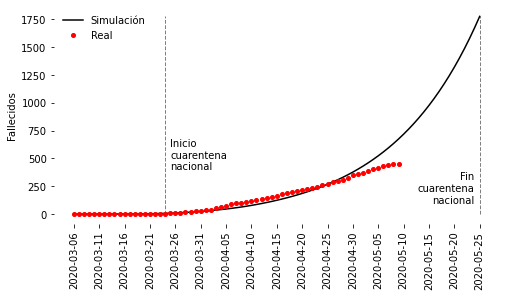

In [181]:
plt.figure(figsize=(8, 4))

plt.plot(range(T), sim.pob_fallecida[:T], "-k", label="Simulación")
plt.plot(
    range(len(diarios)), diarios.total_fallecidos, "or", markersize=4, label="Real"
)
plt.legend(loc="best", frameon=False)

plt.vlines(
    18, ymin=0, ymax=sim.pob_fallecida.max(), linestyle="--", color="gray", linewidth=1,
)

plt.vlines(
    T - 1,
    ymin=0,
    ymax=sim.pob_fallecida.max(),
    linestyle="--",
    color="gray",
    linewidth=1,
)

plt.text(19, 400, "Inicio\ncuarentena\nnacional", ha="left")
plt.text(T - 2, 100, "Fin\ncuarentena\nnacional", ha="right")

fechas = pd.date_range(start=data.fecha_diagnostico.min(), periods=T)
fechas = fechas.map(lambda w: w.strftime("%Y-%m-%d"))
pos = list(range(0, T, 5))
plt.xticks(ticks=pos, labels=fechas[pos], rotation="vertical")

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.gca().spines["left"].set_visible(False)
plt.gca().spines["bottom"].set_visible(False)

plt.ylabel('Fallecidos')

plt.show()

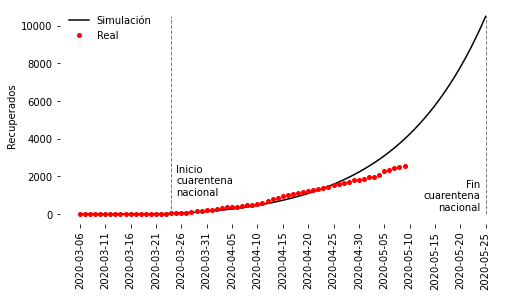

In [182]:
plt.figure(figsize=(8, 4))

plt.plot(range(T), sim.pob_recuperada[:T], "-k", label="Simulación")
plt.plot(
    range(len(diarios)), diarios.total_recuperados, "or", markersize=4, label="Real"
)
plt.legend(loc="best", frameon=False)

plt.vlines(
    18,
    ymin=0,
    ymax=sim.pob_recuperada.max(),
    linestyle="--",
    color="gray",
    linewidth=1,
)

plt.vlines(
    T - 1,
    ymin=0,
    ymax=sim.pob_recuperada.max(),
    linestyle="--",
    color="gray",
    linewidth=1,
)

plt.text(19, 1000, "Inicio\ncuarentena\nnacional", ha="left")
plt.text(T - 2, 200, "Fin\ncuarentena\nnacional", ha="right")

fechas = pd.date_range(start=data.fecha_diagnostico.min(), periods=T)
fechas = fechas.map(lambda w: w.strftime("%Y-%m-%d"))
pos = list(range(0, T, 5))
plt.xticks(ticks=pos, labels=fechas[pos], rotation="vertical")

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.gca().spines["left"].set_visible(False)
plt.gca().spines["bottom"].set_visible(False)

plt.ylabel('Recuperados')

plt.show()

# Simulación largo plazo

In [183]:
T = 400

sim_min = SIR(
    tasa_contagio=[tasa_opt_contagio_1] * 19
    + [tasa_opt_contagio_2] * (66 - 19)
    + [tasa_opt_contagio_2] * (T - 66),
    tasa_recuperacion=tasa_opt_recuperacion,
    tasa_fallecimiento=tasa_opt_fallecimiento,
    importados=diarios.importados,
    T=T,
    poblacion_inicial=48223786,
)

sim_1100 = SIR(
    tasa_contagio=[tasa_opt_contagio_1] * 19
    + [tasa_opt_contagio_2] * (66 - 19)
    + [0.1100] * (T - 66),
    tasa_recuperacion=tasa_opt_recuperacion,
    tasa_fallecimiento=tasa_opt_fallecimiento,
    importados=diarios.importados,
    T=T,
    poblacion_inicial=48223786,
)


sim_1250 = SIR(
    tasa_contagio=[tasa_opt_contagio_1] * 19
    + [tasa_opt_contagio_2] * (66 - 19)
    + [0.1250] * (T - 66),
    tasa_recuperacion=tasa_opt_recuperacion,
    tasa_fallecimiento=tasa_opt_fallecimiento,
    importados=diarios.importados,
    T=T,
    poblacion_inicial=48223786,
)

sim_max = SIR(
    tasa_contagio=[tasa_opt_contagio_1] * 19
    + [tasa_opt_contagio_2] * (66 - 19)
    + [tasa_opt_contagio_1] * (T - 66),
    tasa_recuperacion=tasa_opt_recuperacion,
    tasa_fallecimiento=tasa_opt_fallecimiento,
    importados=diarios.importados,
    T=T,
    poblacion_inicial=48223786,
)

In [184]:
sim_min.contagios.max(), sim_max.contagios.max()

(586945.7877643601, 1209101.553137629)

In [185]:
colors = [plt.cm.Greys((0.3 + 0.7 * float(i) / 4.0)) for i in range(4)]

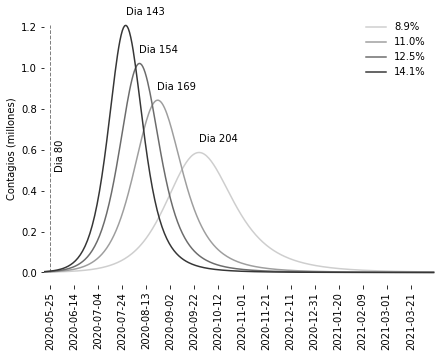

In [186]:
plt.figure(figsize=(7, 5))

plt.plot(
    sim_min.contagios.map(lambda x: x / 1000000.0),
    "-",
    color=colors[0],
    label="{:3.1f}%".format(tasa_opt_contagio_2 * 100),
)
plt.plot(
    sim_1100.contagios.map(lambda x: x / 1000000.0), "-", color=colors[1], label="11.0%"
)
plt.plot(
    sim_1250.contagios.map(lambda x: x / 1000000.0), "-", color=colors[2], label="12.5%"
)
plt.plot(
    sim_max.contagios.map(lambda x: x / 1000000.0),
    "-",
    color=colors[3],
    label="{:3.1f}%".format(tasa_opt_contagio_1 * 100),
)
plt.ylabel("Contagios (millones)")

plt.legend(loc="best", frameon=False)
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.gca().spines["left"].set_visible(False)
plt.gca().spines["bottom"].set_visible(False)

fechas = pd.date_range(start=data.fecha_diagnostico.min(), periods=T)
fechas = fechas.map(lambda w: w.strftime("%Y-%m-%d"))
pos = list(range(0, T, 20))
plt.xticks(ticks=pos, labels=fechas[pos], rotation="vertical")


plt.text(
    sim_min.contagios.idxmax(),
    0.05 + sim_min.contagios.max() / 1000000,
    "Dia {:d}".format(sim_min.contagios.idxmax()),
    ha="left",
)

plt.text(
    sim_1100.contagios.idxmax(),
    0.05 + sim_1100.contagios.max() / 1000000,
    "Dia {:d}".format(sim_1100.contagios.idxmax()),
    ha="left",
)

plt.text(
    sim_1250.contagios.idxmax(),
    0.05 + sim_1250.contagios.max() / 1000000,
    "Dia {:d}".format(sim_1250.contagios.idxmax()),
    ha="left",
)

plt.text(
    sim_max.contagios.idxmax(),
    0.05 + sim_max.contagios.max() / 1000000,
    "Dia {:d}".format(sim_max.contagios.idxmax()),
    ha="left",
)


plt.vlines(
    80,
    ymin=0,
    ymax=sim_max.contagios.max() / 1000000,
    linestyle="--",
    color="gray",
    linewidth=1,
)

plt.text(84, 0.5, "Dia 80", ha="left", rotation=90)
plt.xlim(75, 400)
plt.show()

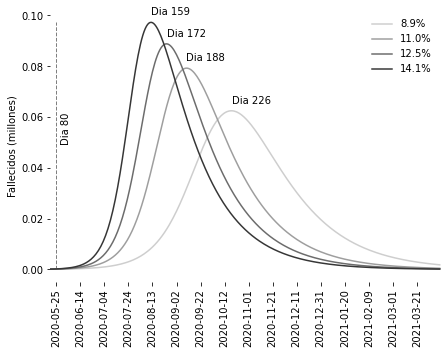

In [187]:
plt.figure(figsize=(7, 5))

plt.plot(
    sim_min.fallecidos.map(lambda x: x / 1000000.0),
    "-",
    color=colors[0],
    label="{:3.1f}%".format(tasa_opt_contagio_2 * 100),
)
plt.plot(
    sim_1100.fallecidos.map(lambda x: x / 1000000.0),
    "-",
    color=colors[1],
    label="11.0%",
)
plt.plot(
    sim_1250.fallecidos.map(lambda x: x / 1000000.0),
    "-",
    color=colors[2],
    label="12.5%",
)
plt.plot(
    sim_max.fallecidos.map(lambda x: x / 1000000.0),
    "-",
    color=colors[3],
    label="{:3.1f}%".format(tasa_opt_contagio_1 * 100),
)
plt.ylabel("Fallecidos (millones)")

plt.legend(loc="best", frameon=False)
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.gca().spines["left"].set_visible(False)
plt.gca().spines["bottom"].set_visible(False)

fechas = pd.date_range(start=data.fecha_diagnostico.min(), periods=T)
fechas = fechas.map(lambda w: w.strftime("%Y-%m-%d"))
pos = list(range(0, T, 20))
plt.xticks(ticks=pos, labels=fechas[pos], rotation="vertical")

plt.text(
    sim_min.fallecidos.idxmax(),
    0.003 + sim_min.fallecidos.max() / 1000000,
    "Dia {:d}".format(sim_min.fallecidos.idxmax()),
    ha="left",
)

plt.text(
    sim_1100.fallecidos.idxmax(),
    0.003 + sim_1100.fallecidos.max() / 1000000,
    "Dia {:d}".format(sim_1100.fallecidos.idxmax()),
    ha="left",
)

plt.text(
    sim_1250.fallecidos.idxmax(),
    0.003 + sim_1250.fallecidos.max() / 1000000,
    "Dia {:d}".format(sim_1250.fallecidos.idxmax()),
    ha="left",
)

plt.text(
    sim_max.fallecidos.idxmax(),
    0.003 + sim_max.fallecidos.max() / 1000000,
    "Dia {:d}".format(sim_max.fallecidos.idxmax()),
    ha="left",
)


plt.vlines(
    80,
    ymin=0,
    ymax=sim_max.fallecidos.max() / 1000000,
    linestyle="--",
    color="gray",
    linewidth=1,
)

plt.text(84, 0.05, "Dia 80", ha="left", rotation=90)
plt.xlim(75, 400)
plt.show()

In [188]:
sim_min.fallecidos.max(), sim_max.fallecidos.max()

(62435.193561652006, 97237.79650267106)

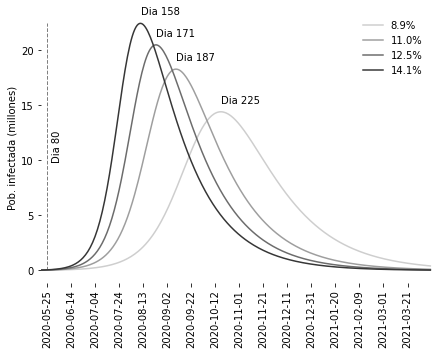

In [189]:
plt.figure(figsize=(7, 5))

plt.plot(
    sim_min.pob_infectada.map(lambda x: x / 1000000.0),
    "-",
    color=colors[0],
    label="{:3.1f}%".format(tasa_opt_contagio_2 * 100),
)
plt.plot(
    sim_1100.pob_infectada.map(lambda x: x / 1000000.0),
    "-",
    color=colors[1],
    label="11.0%",
)
plt.plot(
    sim_1250.pob_infectada.map(lambda x: x / 1000000.0),
    "-",
    color=colors[2],
    label="12.5%",
)
plt.plot(
    sim_max.pob_infectada.map(lambda x: x / 1000000.0),
    "-",
    color=colors[3],
    label="{:3.1f}%".format(tasa_opt_contagio_1 * 100),
)
plt.ylabel("Pob. infectada (millones)")

plt.legend(loc="best", frameon=False)
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.gca().spines["left"].set_visible(False)
plt.gca().spines["bottom"].set_visible(False)

fechas = pd.date_range(start=data.fecha_diagnostico.min(), periods=T)
fechas = fechas.map(lambda w: w.strftime("%Y-%m-%d"))
pos = list(range(0, T, 20))
plt.xticks(ticks=pos, labels=fechas[pos], rotation="vertical")

plt.text(
    sim_min.pob_infectada.idxmax(),
    0.8 + sim_min.pob_infectada.max() / 1000000,
    "Dia {:d}".format(sim_min.pob_infectada.idxmax()),
    ha="left",
)

plt.text(
    sim_1100.pob_infectada.idxmax(),
    0.8 + sim_1100.pob_infectada.max() / 1000000,
    "Dia {:d}".format(sim_1100.pob_infectada.idxmax()),
    ha="left",
)

plt.text(
    sim_1250.pob_infectada.idxmax(),
    0.8 + sim_1250.pob_infectada.max() / 1000000,
    "Dia {:d}".format(sim_1250.pob_infectada.idxmax()),
    ha="left",
)

plt.text(
    sim_max.pob_infectada.idxmax(),
    0.8 + sim_max.pob_infectada.max() / 1000000,
    "Dia {:d}".format(sim_max.pob_infectada.idxmax()),
    ha="left",
)


plt.vlines(
    80,
    ymin=0,
    ymax=sim_max.pob_infectada.max() / 1000000,
    linestyle="--",
    color="gray",
    linewidth=1,
)

plt.text(84, 10.0, "Dia 80", ha="left", rotation=90)
plt.xlim(75, 400)
plt.show()

In [190]:
sim_min.pob_infectada.max(), sim_max.pob_infectada.max()

(14413567.246843895, 22447972.67173055)

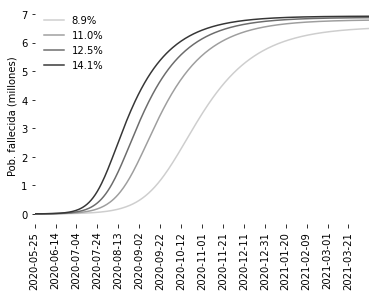

In [191]:
plt.plot(
    sim_min.pob_fallecida.map(lambda x: x / 1000000.0),
    "-",
    color=colors[0],
    label="{:3.1f}%".format(tasa_opt_contagio_2 * 100),
)
plt.plot(
    sim_1100.pob_fallecida.map(lambda x: x / 1000000.0),
    "-",
    color=colors[1],
    label="11.0%",
)
plt.plot(
    sim_1250.pob_fallecida.map(lambda x: x / 1000000.0),
    "-",
    color=colors[2],
    label="12.5%",
)
plt.plot(
    sim_max.pob_fallecida.map(lambda x: x / 1000000.0),
    "-",
    color=colors[3],
    label="{:3.1f}%".format(tasa_opt_contagio_1 * 100),
)
plt.ylabel("Pob. fallecida (millones)")

plt.legend(loc="best", frameon=False)
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.gca().spines["left"].set_visible(False)
plt.gca().spines["bottom"].set_visible(False)

fechas = pd.date_range(start=data.fecha_diagnostico.min(), periods=T)
fechas = fechas.map(lambda w: w.strftime("%Y-%m-%d"))
pos = list(range(0, T, 20))
plt.xticks(ticks=pos, labels=fechas[pos], rotation="vertical")


plt.xlim(80, 400)
plt.show()

---

In [ ]:
plt.plot(sim_min.contagios.map(lambda x: x / 1000000.0), "-r")
plt.plot(sim_min.fallecidos.map(lambda x: x / 1000000.0), "-b")
plt.plot(sim_min.recuperados.map(lambda x: x / 1000000.0), "-g")
plt.grid(color="lightgray", linestyle="--")
plt.show()

In [ ]:
plt.plot(sim_max.pob_infectada, "-r")
plt.plot(sim_max.pob_recuperada, "-g")
plt.plot(sim_max.pob_fallecida, "-b")
plt.grid(color="lightgray", linestyle="--")
plt.show()

---

In [ ]:
plt.plot(sim_1388.contagios.map(lambda x: x / 1000000.0), "-r")
plt.plot(sim_1388.fallecidos.map(lambda x: x / 1000000.0), "-b")
plt.plot(sim_1388.recuperados.map(lambda x: x / 1000000.0), "-g")
plt.grid(color="lightgray", linestyle="--")
plt.show()

In [ ]:
plt.plot(sim_0907.pob_infectada, "-r")
plt.plot(sim_0907.pob_recuperada, "-g")
plt.plot(sim_0907.pob_fallecida, "-b")
plt.grid(color="lightgray", linestyle="--")
plt.show()

In [1]:
import pandas as pd

In [2]:
pd.DataFrame({'a': [1, 2, 3]})

,a
0,1
1,2
2,3
